In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving quikr_car.csv to quikr_car.csv


In [ ]:
import os
print(os.listdir())

['.config', 'quikr_car.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("quikr_car.csv")
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [ ]:
df.shape

(892, 6)

In [ ]:
df.info

<bound method DataFrame.info of                                        name    company  year          Price  \
0      Hyundai Santro Xing XO eRLX Euro III    Hyundai  2007         80,000   
1                   Mahindra Jeep CL550 MDI   Mahindra  2006       4,25,000   
2                Maruti Suzuki Alto 800 Vxi     Maruti  2018  Ask For Price   
3    Hyundai Grand i10 Magna 1.2 Kappa VTVT    Hyundai  2014       3,25,000   
4          Ford EcoSport Titanium 1.5L TDCi       Ford  2014       5,75,000   
..                                      ...        ...   ...            ...   
887                                      Ta       Tara  zest       3,10,000   
888                     Tata Zest XM Diesel       Tata  2018       2,60,000   
889                      Mahindra Quanto C8   Mahindra  2013       3,90,000   
890                Honda Amaze 1.2 E i VTEC      Honda  2014       1,80,000   
891               Chevrolet Sail 1.2 LT ABS  Chevrolet  2014       1,60,000   

     kms_driven fuel_type  
0    45,000 kms    Petrol  
1        40 kms    Diesel  
2    22,000 kms    Petrol  
3    28,000 kms    Petrol  
4    36,000 kms    Diesel  
..          ...       ...  
887         NaN       NaN  
888  27,000 kms    Diesel  
889  40,000 kms    Diesel  
890      Petrol       NaN  
891      Petrol       NaN  

[892 rows x 6 columns]>

In [ ]:
df['year'].unique()

array(['2007', '2006', '2018', '2014', '2015', '2012', '2013', '2016',
       '2010', '2017', '2008', '2011', '2019', '2009', '2005', '2000',
       '...', '150k', 'TOUR', '2003', 'r 15', '2004', 'Zest', '/-Rs',
       'sale', '1995', 'ara)', '2002', 'SELL', '2001', 'tion', 'odel',
       '2 bs', 'arry', 'Eon', 'o...', 'ture', 'emi', 'car', 'able', 'no.',
       'd...', 'SALE', 'digo', 'sell', 'd Ex', 'n...', 'e...', 'D...',
       ', Ac', 'go .', 'k...', 'o c4', 'zire', 'cent', 'Sumo', 'cab',
       't xe', 'EV2', 'r...', 'zest'], dtype=object)

In [ ]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')

In [ ]:
df = df.dropna(subset=['year'])

In [ ]:
df['year'] = df['year'].astype(int)

/tmp/ipykernel_13157/1483339248.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['year'].astype(int)


In [ ]:
car=df[df['Price']!='Ask For Price']

In [ ]:
car=df[df['fuel_type'].isna()]

In [ ]:
car['kms_driven']=car['kms_driven'].str.split().str.get(0).str.replace(',','')

/tmp/ipykernel_13157/3248255987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car['kms_driven']=car['kms_driven'].str.split().str.get(0).str.replace(',','')


In [ ]:
car=df[df['year'].str.isnumeric()]

In [ ]:
df.shape

(842, 6)

In [ ]:
car['name']=df['name'].str.split().str.slice(start=0,stop=3).str.join(' ')

/tmp/ipykernel_13157/713913320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  car['name']=df['name'].str.split().str.slice(start=0,stop=3).str.join(' ')


In [ ]:
car=df.reset_index(drop=True)

In [ ]:
car

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel
...,...,...,...,...,...,...
837,Toyota Corolla Altis,Toyota,2009,"3,00,000","1,32,000 kms",Petrol
838,Tata Zest XM Diesel,Tata,2018,"2,60,000","27,000 kms",Diesel
839,Mahindra Quanto C8,Mahindra,2013,"3,90,000","40,000 kms",Diesel
840,Honda Amaze 1.2 E i VTEC,Honda,2014,"1,80,000",Petrol,NaN


In [ ]:
df.describe(include='all')

,name,company,year,Price,kms_driven,fuel_type
count,842,842,842.000000,842,840,837
unique,476,26,NaN,273,258,3
top,Honda City,Maruti,NaN,Ask For Price,"45,000 kms",Petrol
freq,13,229,NaN,23,30,440
mean,NaN,NaN,2012.523753,NaN,NaN,NaN
std,NaN,NaN,4.024601,NaN,NaN,NaN
min,NaN,NaN,1995.000000,NaN,NaN,NaN
25%,NaN,NaN,2010.000000,NaN,NaN,NaN
50%,NaN,NaN,2013.000000,NaN,NaN,NaN
75%,NaN,NaN,2015.000000,NaN,NaN,NaN


In [ ]:
df['company'].unique()

array(['Hyundai', 'Mahindra', 'Maruti', 'Ford', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'I', 'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat',
       'Force', 'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'],
      dtype=object)

In [ ]:
import seaborn as sns

/tmp/ipykernel_13157/2788130517.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')


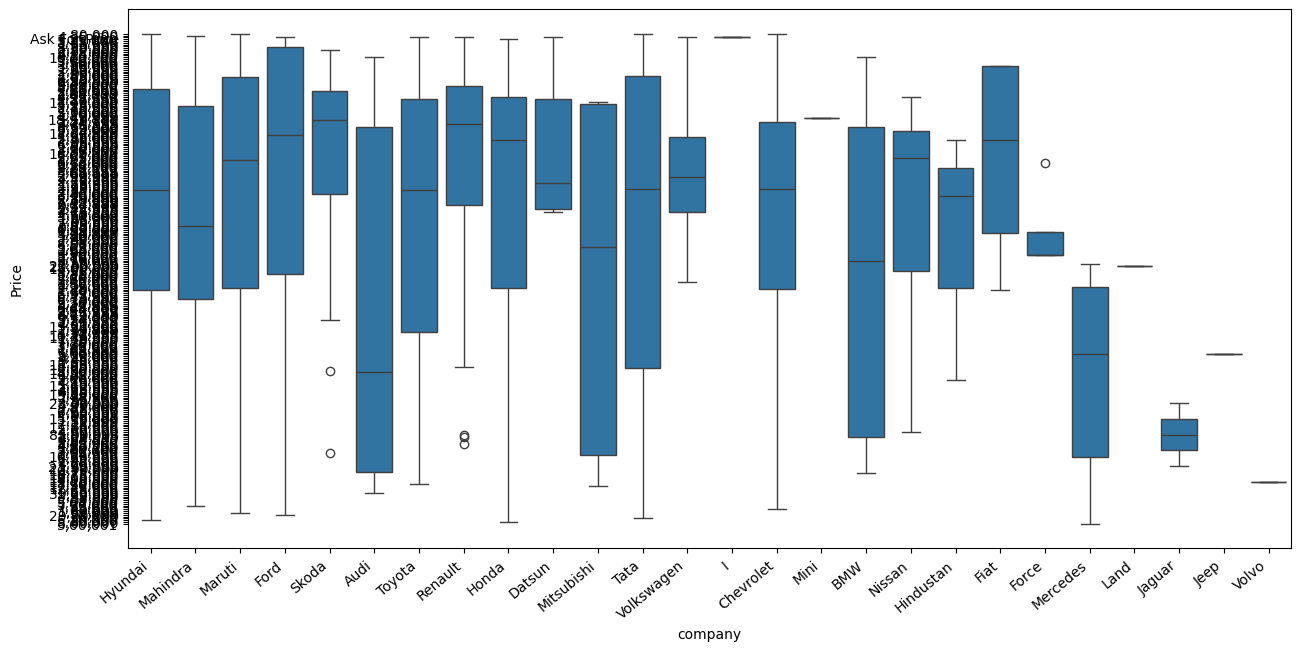

In [ ]:
plt.subplots(figsize=(15,7))
ax=sns.boxplot(x='company',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 60.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 44.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be plac

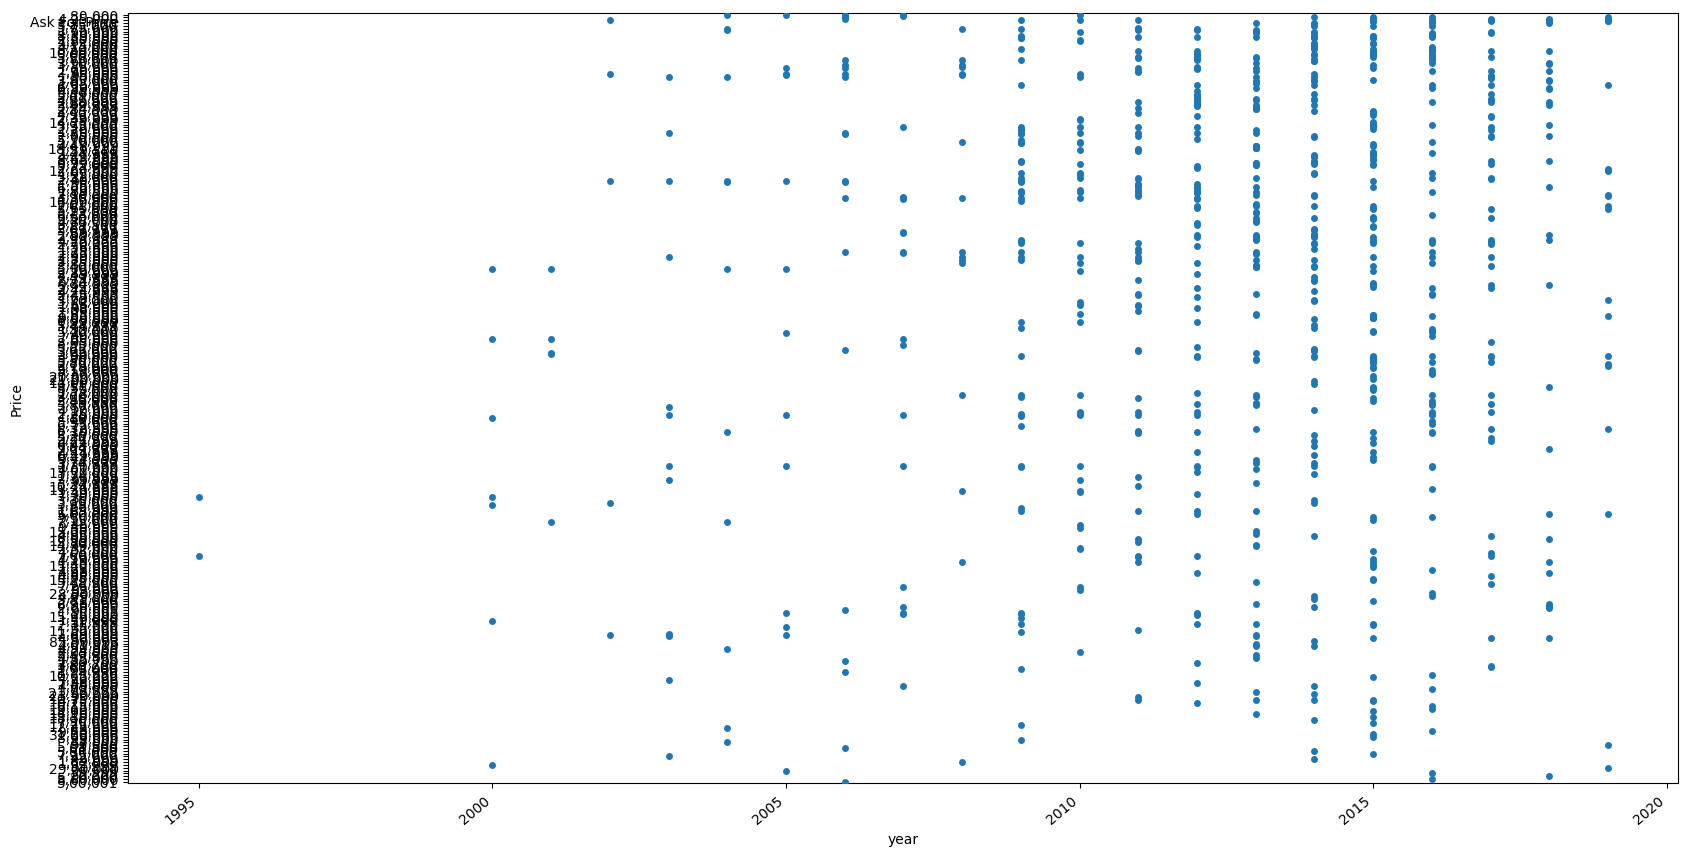

In [ ]:
plt.subplots(figsize=(20,10))
ax=sns.swarmplot(x='year',y='Price',data=car)
ax.set_xticklabels(ax.get_xticklabels(),rotation=40,ha='right')
plt.show()

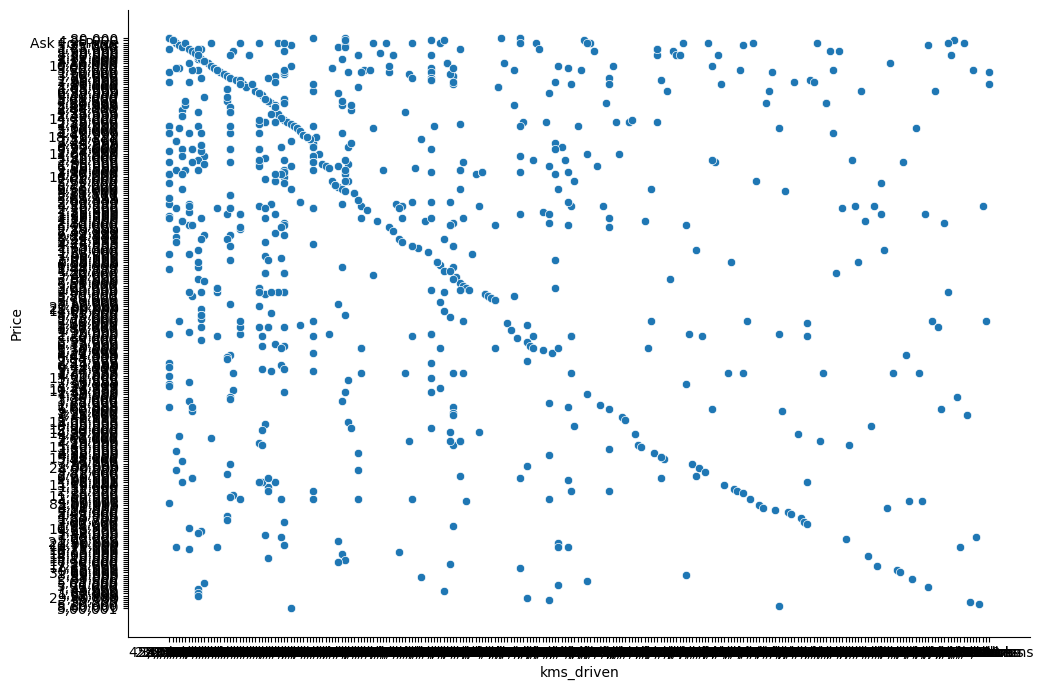

In [ ]:
sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5)

<Axes: xlabel='fuel_type', ylabel='Price'>

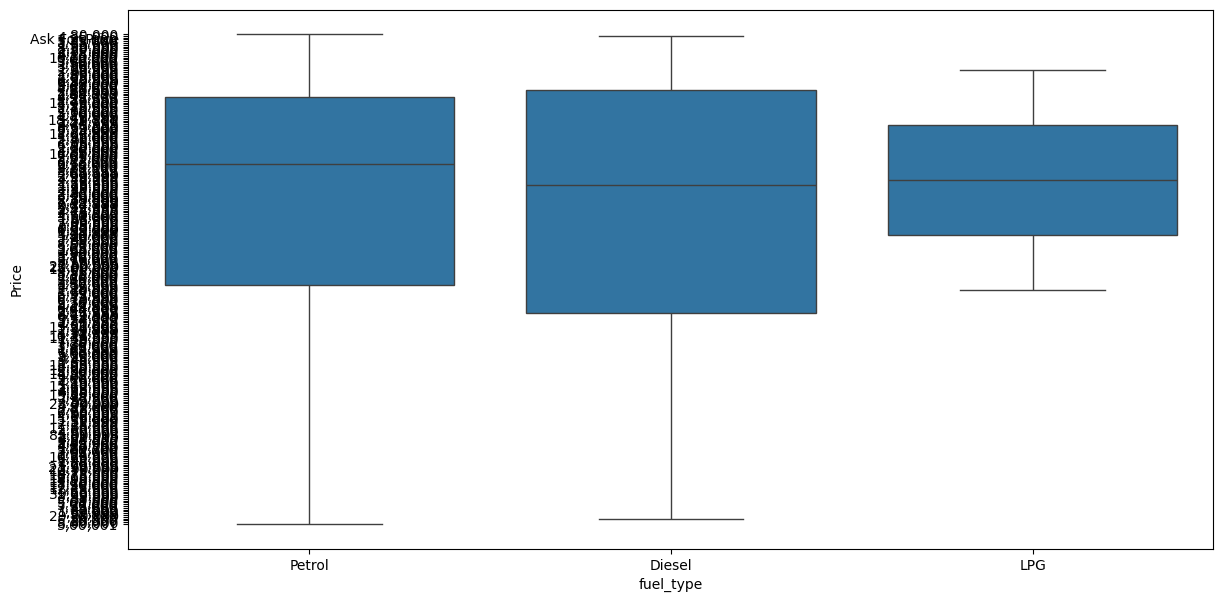

In [ ]:
plt.subplots(figsize=(14,7))
sns.boxplot(x='fuel_type',y='Price',data=car)

In [ ]:
X=car[['name','company','year','kms_driven','fuel_type']]
y=df['Price']

In [ ]:
X

,name,company,year,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"36,000 kms",Diesel
...,...,...,...,...,...
837,Toyota Corolla Altis,Toyota,2009,"1,32,000 kms",Petrol
838,Tata Zest XM Diesel,Tata,2018,"27,000 kms",Diesel
839,Mahindra Quanto C8,Mahindra,2013,"40,000 kms",Diesel
840,Honda Amaze 1.2 E i VTEC,Honda,2014,Petrol,NaN


In [ ]:
y.shape

(842,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [ ]:
ohe=OneHotEncoder()
ohe.fit(X[['name','company','fuel_type']])

OneHotEncoder()

In [ ]:
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['name','company','fuel_type']),
                                    remainder='passthrough')

In [ ]:
lr=LinearRegression()

In [ ]:
pipe=make_pipeline(column_trans,lr)

In [ ]:
df['kms_driven'] = df['kms_driven'].str.replace(' kms','')
df['kms_driven'] = df['kms_driven'].str.replace(',','')
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

/tmp/ipykernel_13157/4090457267.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kms_driven'] = df['kms_driven'].str.replace(' kms','')
/tmp/ipykernel_13157/4090457267.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kms_driven'] = df['kms_driven'].str.replace(',','')
/tmp/ipykernel_13157/4090457267.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [ ]:
df['kms_driven'].isnull().sum()

np.int64(4)

In [ ]:
df = df.dropna(subset=['kms_driven'])

In [ ]:
df['kms_driven'] = df['kms_driven'].astype(int)

In [ ]:
df['kms_driven'].head()

,kms_driven
0,45000
1,40
2,22000
3,28000
4,36000


In [ ]:
X = df.drop(columns=['Price'])   # replace Price with your target column name
y = df['Price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df['Price'].head()

,Price
0,"80,000"
1,"4,25,000"
2,Ask For Price
3,"3,25,000"
4,"5,75,000"


In [ ]:
X = df.drop(columns=['Price'])
y = df['Price']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace(',', '', regex=False)

# Convert to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=['Price'])

# Convert to int
df['Price'] = df['Price'].astype(int)

In [ ]:
print(df.dtypes)

name          object
company       object
year           int64
Price          int64
kms_driven     int64
fuel_type     object
dtype: object


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

ohe = OneHotEncoder(handle_unknown='ignore')

column_trans = ColumnTransformer(
    [('ohe', ohe, ['name','company','fuel_type'])],
    remainder='passthrough'
)

pipe = Pipeline([
    ('transformer', column_trans),
    ('model', LinearRegression())
])

In [ ]:
# Re-define X and y from the cleaned df.
# This ensures 'Price' and 'kms_driven' columns are in numeric format.
# Assumes 'df' has been cleaned as per previous steps (e.g., cell lAeOoLYub-6V for 'Price').
X = df.drop(columns=['Price'])
y = df['Price']

# Re-split the data to ensure X_train and y_train are correctly formatted.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now fit the pipeline with the correctly formatted data.
pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('model', LinearRegression())])

In [ ]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['name', 'company',
                                                   'fuel_type'])])),
                ('model', LinearRegression())])

In [ ]:
y_pred=pipe.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.20755119350768914

In [ ]:
scores=[]
for i in range(1000):
    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=i)
    lr=LinearRegression()
    pipe=make_pipeline(column_trans,lr)
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

In [ ]:
np.argmax(scores)

655

In [ ]:
pipe.predict(pd.DataFrame(columns=X_test.columns,data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([486408.17082943])

In [ ]:
scores[np.argmax(scores)]

0.8804612182107503

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans,lr)
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test,y_pred)

0.8804612182107503

In [ ]:
import pickle

In [ ]:
pickle.dump(pipe,open('LinearRegressionModel.pkl','wb'))

In [ ]:
pipe.predict(pd.DataFrame(columns=['name','company','year','kms_driven','fuel_type'],data=np.array(['Maruti Suzuki Swift','Maruti',2019,100,'Petrol']).reshape(1,5)))

array([488956.9276296])

In [ ]:
pipe.steps[0][1].transformers[0][1].categories[0]

'a'